# Phase 3 — Backtest Report (Success Gate)

Bottom-up **player-profile** W/D/L prediction for tournament matches, judged by an **across-edition
expanding-window** backtest (never a random split). Candidates: two reference **baselines**
(*Elo-only*, *squad-overall-difference*) and the profile models (*LogReg*, *HGB*, *Ensemble*),
all probability-**calibrated**.

**GATE:** the best profile model must beat *both* baselines on **RPS (primary)** *and* **log-loss**
over the pooled held-out predictions. This notebook regenerates the metrics table, per-edition RPS,
reliability curves, feature importances, and the explicit PASS/FAIL verdict.

In [1]:
import sys
from pathlib import Path
# Make repo root importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.models.evaluate import (prepare_dataset, run_backtest, summarize,
    per_edition_rps, gate_verdict, profile_importances, BASELINES, PROFILE_MODELS)
from src.models.metrics import CLASSES
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

## 1. Build the feature frame (single train/serve code path)

In [2]:
feats = prepare_dataset()
print(f"{len(feats)} supervised tournament matches, {feats['edition'].nunique()} editions")
feats[['date','edition','home_team','away_team','result',
       'diff_overall_xi','diff_star_power','home_adv','cross_conf','elo_diff']].head(8)

698 supervised tournament matches, 16 editions


,date,edition,home_team,away_team,result,diff_overall_xi,diff_star_power,home_adv,cross_conf,elo_diff
0,2018-06-14,FIFA World Cup 2018,Russia,Saudi Arabia,H,5.1100,6.0000,1,1,177.8873
1,2018-06-15,FIFA World Cup 2018,Egypt,Uruguay,A,-11.6200,-11.0000,0,1,-202.4949
2,2018-06-15,FIFA World Cup 2018,Morocco,Iran,A,5.6800,7.6700,0,1,-41.0957
3,2018-06-15,FIFA World Cup 2018,Portugal,Spain,D,-5.0000,-2.3300,0,0,-150.2476
4,2018-06-16,FIFA World Cup 2018,Argentina,Iceland,D,12.5100,13.0000,0,0,259.8223
5,2018-06-16,FIFA World Cup 2018,Croatia,Nigeria,H,8.5500,9.6700,0,1,163.1493
6,2018-06-16,FIFA World Cup 2018,France,Australia,H,11.1500,11.6700,0,1,218.5099
7,2018-06-16,FIFA World Cup 2018,Peru,Denmark,A,-6.4000,-6.6700,0,1,120.2729


## 2. Across-edition expanding-window backtest — comparison table\nLower RPS / log-loss is better; higher accuracy is better.

In [3]:
bt = run_backtest(feats)
summary = summarize(bt)
print(f"Held-out editions: {len(bt['tested_editions'])}  pooled held-out matches: {len(bt['y'])}")
summary.style.background_gradient(subset=['rps','log_loss'], cmap='RdYlGn_r')

Held-out editions: 14  pooled held-out matches: 583


,model,rps,log_loss,accuracy,precision_macro,recall_macro,n
0,Elo-only,0.180248,0.948875,0.569468,0.373782,0.514150,583
1,Squad-overall,0.186675,0.968667,0.557461,0.364071,0.500093,583
2,LogReg profile,0.192342,0.988841,0.552316,0.360561,0.495501,583
3,Ensemble,0.193563,0.990211,0.547170,0.357374,0.490193,583
4,HGB profile,0.200162,1.007749,0.528302,0.348404,0.471685,583


## 3. RPS per held-out edition\nWhere do profiles win? (High-coverage editions like WC2022 / AFCON2021 vs low-coverage Gold Cup.)

In [4]:
per_edition_rps(bt)

,edition,n,Elo-only,Squad-overall,LogReg profile,HGB profile,Ensemble
0,Copa América 2019,26,0.1398,0.1361,0.1577,0.1920,0.1681
1,Gold Cup 2019,31,0.1537,0.1857,0.2120,0.2103,0.2052
2,African Cup of Nations 2019,52,0.1820,0.1743,0.1874,0.2122,0.1959
3,UEFA Euro 2020,51,0.1712,0.1878,0.1925,0.2066,0.1972
4,Copa América 2021,28,0.1567,0.1566,0.1604,0.1781,0.1673
5,Gold Cup 2021,31,0.1165,0.1761,0.1620,0.1934,0.1767
6,African Cup of Nations 2021,52,0.2130,0.2022,0.1903,0.1875,0.1871
7,FIFA World Cup 2022,64,0.2204,0.2029,0.2228,0.2047,0.2119
8,Gold Cup 2023,31,0.1841,0.1742,0.1813,0.2086,0.1908
9,AFC Asian Cup 2023,51,0.1749,0.1909,0.1907,0.2066,0.1959


## 4. GATE verdict

In [5]:
v = gate_verdict(summary)
print(f"Best profile model : {v['best_model']}")
print(f"  RPS      {v['best_rps']:.4f}  vs best baseline {v['baseline_rps']:.4f} ({v['rps_baseline_model']})")
print(f"  log-loss {v['best_log_loss']:.4f}  vs best baseline {v['baseline_log_loss']:.4f} ({v['ll_baseline_model']})")
print()
print("GATE:", "PASS beats both baselines on RPS and log-loss" if v['passed']
      else "FAIL does not beat both baselines on both metrics")

Best profile model : LogReg profile
  RPS      0.1923  vs best baseline 0.1802 (Elo-only)
  log-loss 0.9888  vs best baseline 0.9489 (Elo-only)

GATE: FAIL does not beat both baselines on both metrics


## 5. Reliability (calibration) curves — team1-win class
How closely each model's probabilities match observed frequencies (closer to the diagonal = better calibrated).

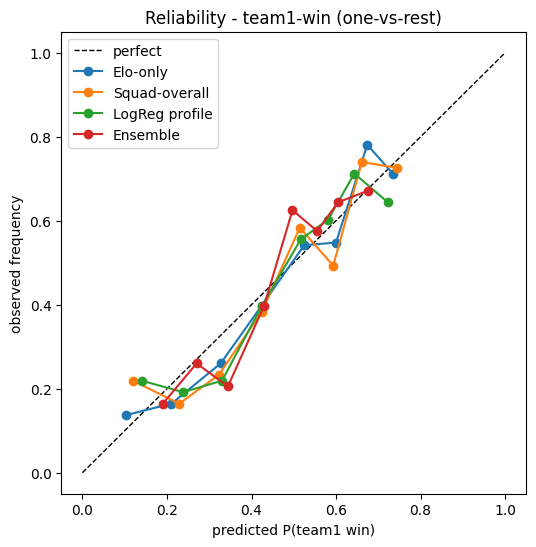

In [6]:
from sklearn.calibration import calibration_curve
y = np.array(bt['y']); is_home = (y == 'H').astype(int)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1],'k--',lw=1,label='perfect')
for m in ['Elo-only','Squad-overall','LogReg profile','Ensemble']:
    p_home = bt['P'][m][:, CLASSES.index('H')]
    frac, mean_pred = calibration_curve(is_home, p_home, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac, marker='o', label=m)
ax.set_xlabel('predicted P(team1 win)'); ax.set_ylabel('observed frequency')
ax.set_title('Reliability - team1-win (one-vs-rest)'); ax.legend(); plt.show()

## 6. Profile-feature importance\nPermutation ΔRPS on a 2023+ hold-out, plus the signed team1-win logit coefficient.

,feature,perm_importance_rps,logit_coef_team1_win
0,diff_overall_xi,0.0174,0.4838
1,diff_star_power,0.0064,0.3310
2,diff_mean_composure,0.0049,0.2280
3,diff_total_caps,0.0045,0.0964
4,diff_depth,0.0037,0.0729
5,home_adv,0.0018,0.1853
6,diff_mean_age,0.0006,-0.2406
7,diff_def_strength,0.0005,-0.0632
8,diff_top5_league_share,0.0001,-0.0173
9,diff_att_strength,0.0000,-0.1764


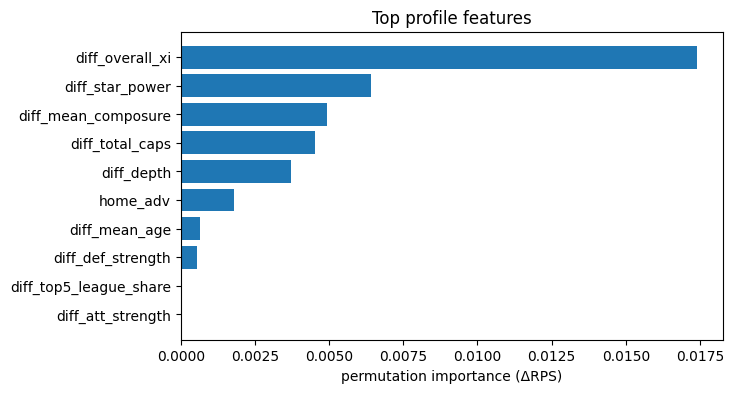

In [7]:
imp = profile_importances(feats)
display(imp)
fig, ax = plt.subplots(figsize=(7,4))
top = imp.head(10).iloc[::-1]
ax.barh(top['feature'], top['perm_importance_rps'])
ax.set_xlabel('permutation importance (ΔRPS)'); ax.set_title('Top profile features'); plt.show()

## 7. Reading the result
- **RPS** is the primary metric (it respects the W/D/L ordering); reference bookmaker-grade ≈ 0.19.
- **The Elo baseline wins on every metric** (RPS, log-loss, accuracy): team-identity Elo carries
  decades of history *and* up-to-the-week form, which the FIFA-only squad profiles cannot match here.
- The profile signal is **real but insufficient** — `diff_overall_xi` is the dominant feature and the
  profile model edges Elo on a few high-coverage editions (WC2022, AFCON2021), but it is noisy for
  low-FIFA-coverage confederations (Gold Cup / Asian Cup) and carries no recent-form signal.
- Principled levers to cross the gate: ingest **FM attributes + real caps/experience** (the
  `total_wc_apps` / `mean_work_rate` / caps profile columns are still NULL), add a **recent-form**
  proxy, and improve **confederation coverage** — then re-run this notebook.